In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(
    "/Users/minhtoan/SE/HocTrenLop/Trí tuệ nhân tạo/"
    "fraud-risk-screening-local-data/"
    "ibm_tabformer/card_transaction.v1.csv"
)

target_counts = Counter()
monthly_total = Counter()
monthly_fraud = Counter()

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=["Year", "Month", "Is Fraud?"],
    chunksize=500_000,
):
    target = chunk["Is Fraud?"].astype("string").str.strip()

    target_counts.update(target.value_counts().to_dict())

    keys = list(zip(chunk["Year"], chunk["Month"]))
    monthly_total.update(keys)

    fraud_mask = target.eq("Yes").fillna(False)
    fraud_keys = list(
        zip(
            chunk.loc[fraud_mask, "Year"],
            chunk.loc[fraud_mask, "Month"],
        )
    )
    monthly_fraud.update(fraud_keys)

print(target_counts)


Counter({'No': 24357143, 'Yes': 29757})


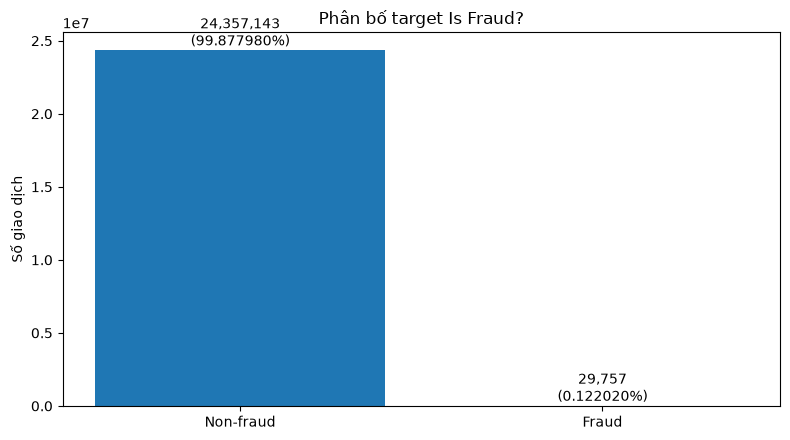

In [2]:
labels = ["Non-fraud", "Fraud"]
values = [
    target_counts["No"],
    target_counts["Yes"],
]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, values)

ax.set_title("Phân bố target Is Fraud?")
ax.set_ylabel("Số giao dịch")

total = sum(values)

for bar, value in zip(bars, values):
    rate = value / total * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}\n({rate:.6f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


In [3]:
rows = []

for key in sorted(monthly_total):
    year, month = key
    total = monthly_total[key]
    fraud = monthly_fraud.get(key, 0)

    rows.append(
        {
            "Year": year,
            "Month": month,
            "transaction_count": total,
            "fraud_count": fraud,
            "fraud_rate_pct": fraud / total * 100,
        }
    )

monthly_df = pd.DataFrame(rows)

monthly_df["period"] = pd.to_datetime(
    {
        "year": monthly_df["Year"],
        "month": monthly_df["Month"],
        "day": 1,
    }
)

monthly_df.tail(18)


,Year,Month,transaction_count,fraud_count,fraud_rate_pct,period
332,2018,9,141557,262,0.185084,2018-09-01
333,2018,10,145473,181,0.124422,2018-10-01
334,2018,11,141843,300,0.211501,2018-11-01
335,2018,12,146263,229,0.156567,2018-12-01
336,2019,1,146097,203,0.138949,2019-01-01
337,2019,2,132102,156,0.118091,2019-02-01
338,2019,3,147202,215,0.146058,2019-03-01
339,2019,4,141409,218,0.154163,2019-04-01
340,2019,5,145648,260,0.178513,2019-05-01
341,2019,6,142399,215,0.150984,2019-06-01


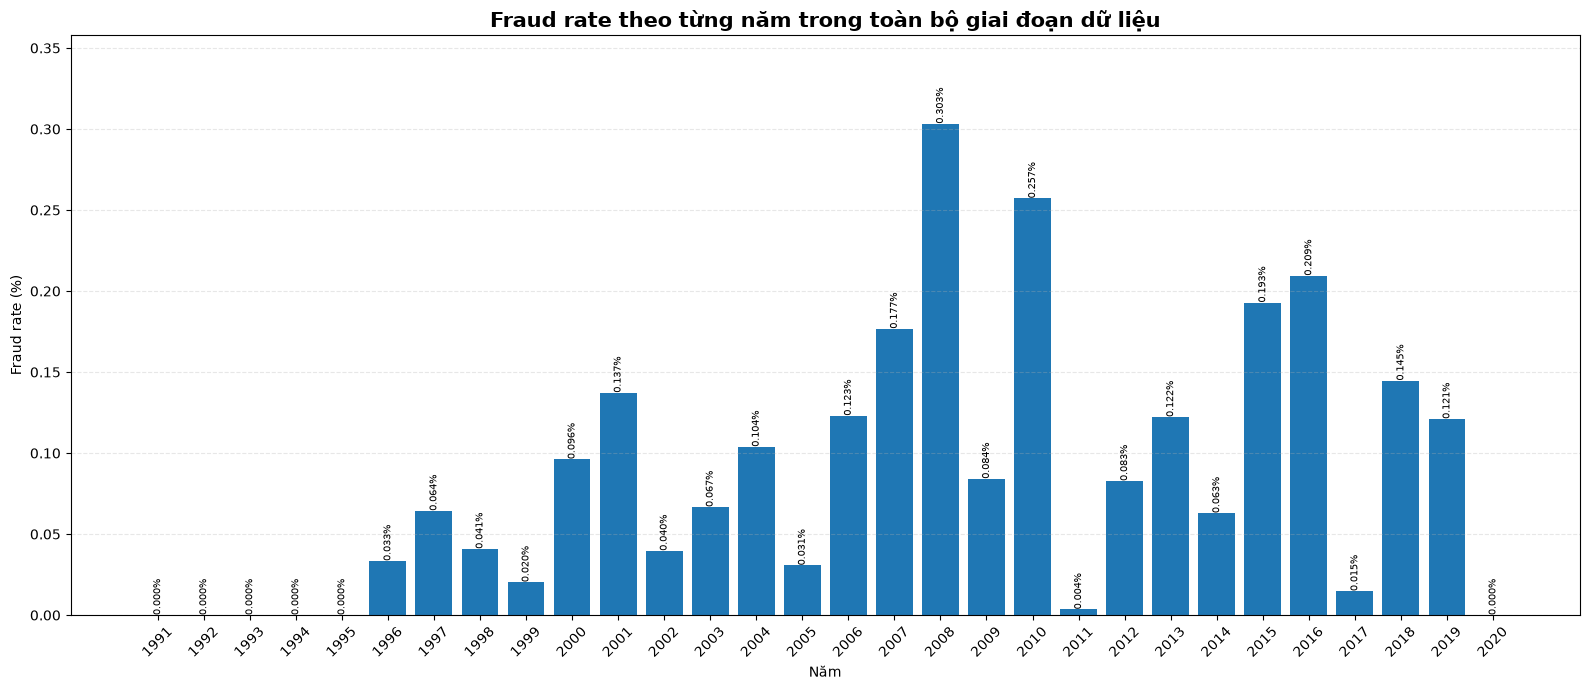

In [4]:
# ============================================================
# Fraud rate theo từng năm trong toàn bộ giai đoạn dữ liệu
# ============================================================

yearly_df = (
    monthly_df
    .groupby("Year", as_index=False)
    .agg(
        transaction_count=("transaction_count", "sum"),
        fraud_count=("fraud_count", "sum"),
    )
)

yearly_df["fraud_rate_pct"] = (
    yearly_df["fraud_count"]
    / yearly_df["transaction_count"]
    * 100
)

# ------------------------------------------------------------
# Vẽ biểu đồ
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 7))

bars = ax.bar(
    yearly_df["Year"].astype(str),
    yearly_df["fraud_rate_pct"],
)

ax.set_title(
    "Fraud rate theo từng năm trong toàn bộ giai đoạn dữ liệu",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Năm")
ax.set_ylabel("Fraud rate (%)")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

# Hiển thị Fraud rate trên mỗi cột
for bar, rate in zip(
    bars,
    yearly_df["fraud_rate_pct"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.3f}%",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90,
    )

ax.set_ylim(
    0,
    yearly_df["fraud_rate_pct"].max() * 1.18,
)

plt.tight_layout()
plt.show()

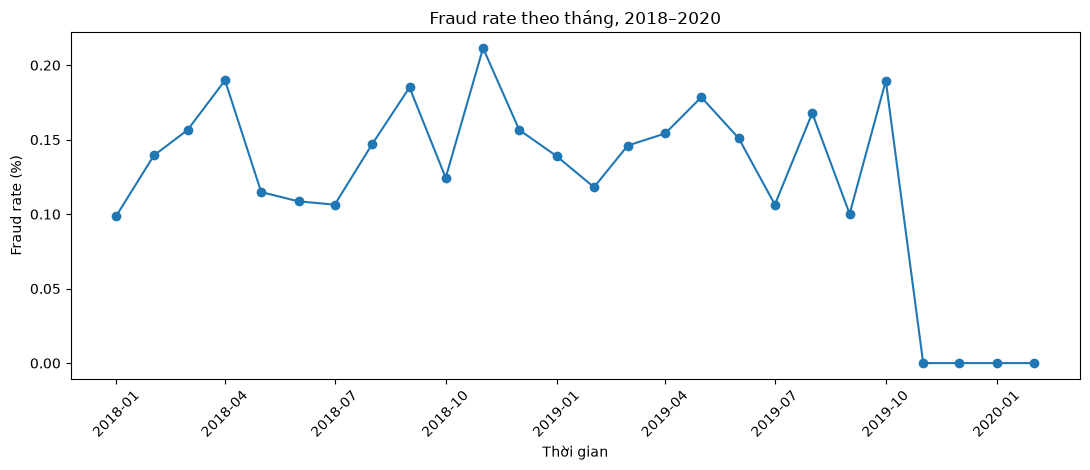

In [5]:
plot_df = monthly_df[
    monthly_df["Year"].between(2018, 2020)
].copy()

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.plot(
    plot_df["period"],
    plot_df["fraud_rate_pct"],
    marker="o",
)

ax.set_title("Fraud rate theo tháng, 2018–2020")
ax.set_xlabel("Thời gian")
ax.set_ylabel("Fraud rate (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Số mẫu Amount dùng để vẽ: 243,869
Median xấp xỉ: 30.18
P95 xấp xỉ: 147.34
P99 xấp xỉ: 320.00
Min trong sample: -500.00
Max trong sample: 3304.86


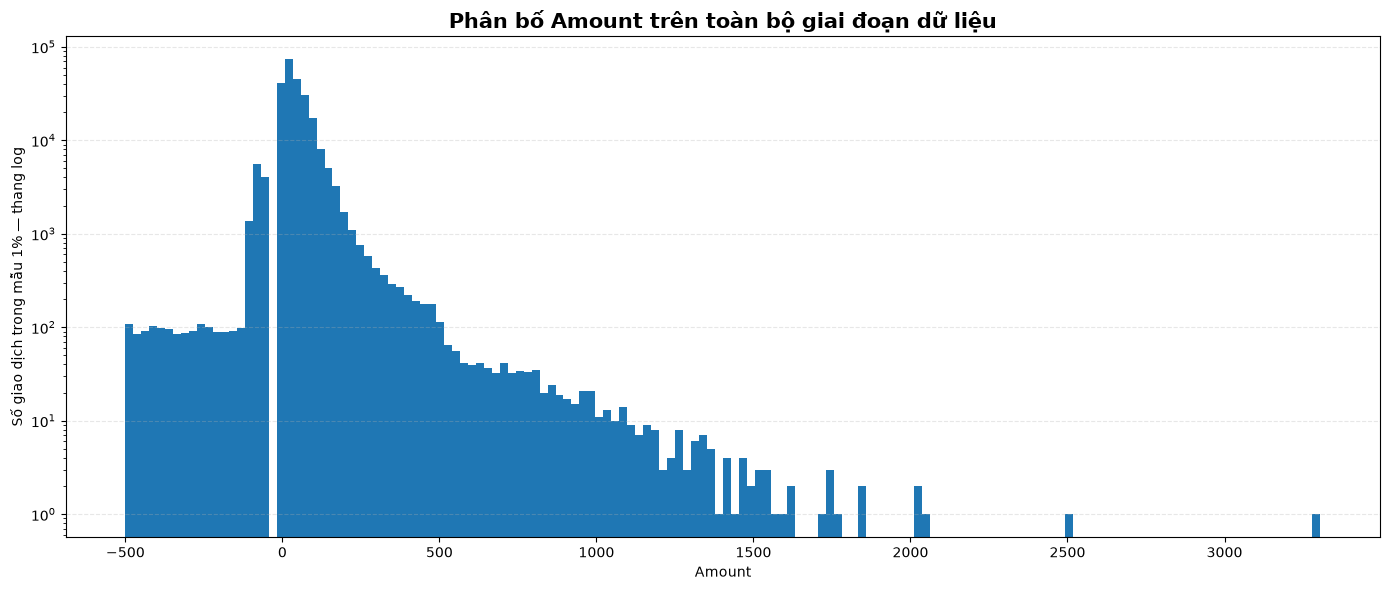

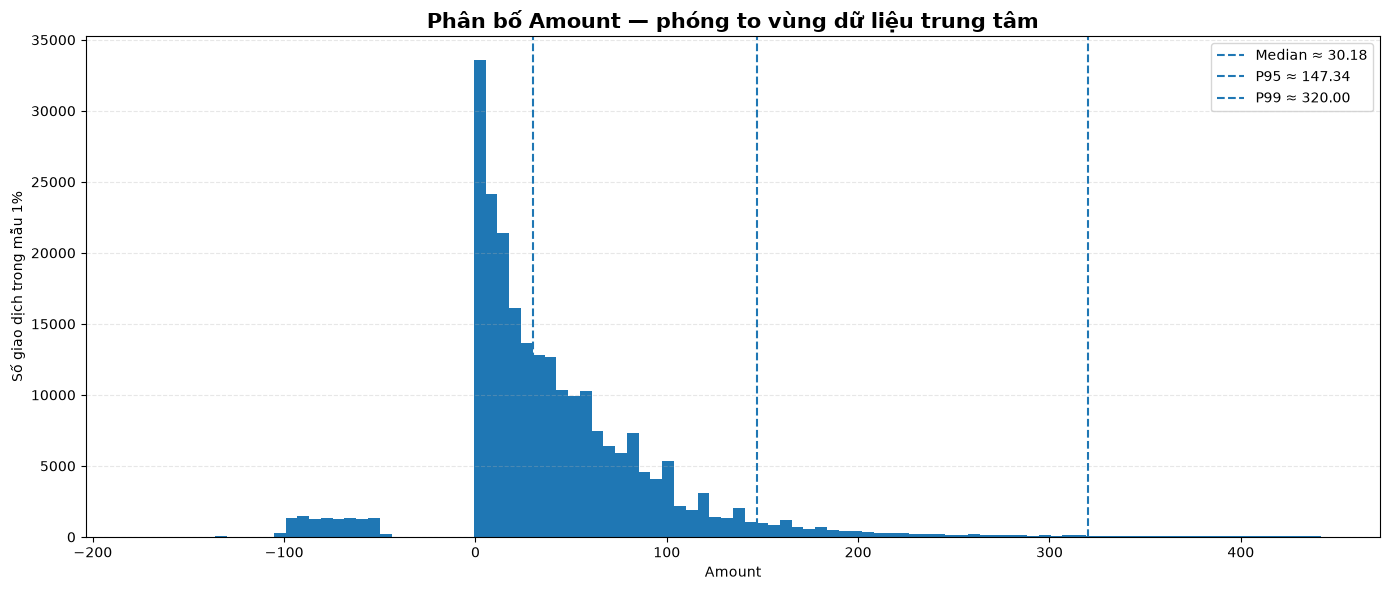

In [6]:
# ============================================================
# Phân bố Amount trong toàn bộ giai đoạn dữ liệu
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

AMOUNT_SAMPLE_FRAC = 0.01
RANDOM_STATE = 42

amount_sample_parts = []

# ------------------------------------------------------------
# Đọc riêng cột Amount theo từng chunk
# và lấy mẫu 1% để trực quan hóa
# ------------------------------------------------------------

for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_PATH,
        usecols=["Amount"],
        chunksize=500_000,
    )
):
    amount_numeric = pd.to_numeric(
        chunk["Amount"]
        .astype("string")
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce",
    )

    valid_amount = amount_numeric.dropna()

    amount_sample_parts.append(
        valid_amount.sample(
            frac=AMOUNT_SAMPLE_FRAC,
            random_state=RANDOM_STATE + chunk_number,
        )
    )

amount_sample = pd.concat(
    amount_sample_parts,
    ignore_index=True,
)

# ------------------------------------------------------------
# Một số mốc dùng để đọc biểu đồ
# ------------------------------------------------------------

p005 = amount_sample.quantile(0.005)
p50 = amount_sample.quantile(0.50)
p95 = amount_sample.quantile(0.95)
p99 = amount_sample.quantile(0.99)
p995 = amount_sample.quantile(0.995)

print(f"Số mẫu Amount dùng để vẽ: {len(amount_sample):,}")
print(f"Median xấp xỉ: {p50:.2f}")
print(f"P95 xấp xỉ: {p95:.2f}")
print(f"P99 xấp xỉ: {p99:.2f}")
print(f"Min trong sample: {amount_sample.min():.2f}")
print(f"Max trong sample: {amount_sample.max():.2f}")


# ============================================================
# BIỂU ĐỒ 1 — Toàn miền Amount
# Dùng log scale ở trục Y để phần đuôi hiếm vẫn nhìn thấy được
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(
    amount_sample,
    bins=150,
)

ax.set_yscale("log")

ax.set_title(
    "Phân bố Amount trên toàn bộ giai đoạn dữ liệu",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Amount")
ax.set_ylabel("Số giao dịch trong mẫu 1% — thang log")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()
plt.show()


# ============================================================
# BIỂU ĐỒ 2 — Phóng to vùng chứa 99% dữ liệu trung tâm
# ============================================================

amount_central = amount_sample[
    amount_sample.between(
        p005,
        p995,
    )
]

fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(
    amount_central,
    bins=100,
)

ax.axvline(
    p50,
    linestyle="--",
    linewidth=1.5,
    label=f"Median ≈ {p50:.2f}",
)

ax.axvline(
    p95,
    linestyle="--",
    linewidth=1.5,
    label=f"P95 ≈ {p95:.2f}",
)

ax.axvline(
    p99,
    linestyle="--",
    linewidth=1.5,
    label=f"P99 ≈ {p99:.2f}",
)

ax.set_title(
    "Phân bố Amount — phóng to vùng dữ liệu trung tâm",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Amount")
ax.set_ylabel("Số giao dịch trong mẫu 1%")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

ax.legend()

plt.tight_layout()
plt.show()